<a href="https://colab.research.google.com/github/Rouba-Os/AI-Course/blob/main/Assignment7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!apt-get install -y git
!git config --global user.email "rouba.osko@students.williscollege.com"
!git config --global user.name "Rouba-Os"

print("Git configured successfully")

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
git is already the newest version (1:2.34.1-1ubuntu1.17).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.
Git configured successfully


In [2]:
!git clone https://github.com/Rouba-Os/AI-Course.git
%cd AI-Course
!ls

Cloning into 'AI-Course'...
remote: Enumerating objects: 27, done.
remote: Counting objects: 100% (27/27), done.
remote: Compressing objects: 100% (25/25), done.
remote: Total 27 (delta 12), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (27/27), 22.94 KiB | 3.82 MiB/s, done.
Resolving deltas: 100% (12/12), done.
/content/AI-Course
AICourse.ipynb	   Assignment3.ipynb  git_github_exercise.ipynb
assignment2.ipynb  Assignment5.ipynb  README.md


In [3]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


In [5]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_squared_error, r2_score

In [6]:
# --- Data Collection and Loading ---
## # Load dataset and convert to DataFrame
housing = fetch_california_housing()

df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['MEDV'] = housing.target

In [7]:
# --- Quick Check of Data ---
## Display the first few rows of the dataset to understand its structur
print('Data first few rows\n', df.head())

## Check the features and target variable. Identify which is continuous and categorical if applicable
print('\nData info\n', df.info())

print('\nData Statistical summary\n', df.describe())

Data first few rows
    MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude   MEDV  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  flo

In [8]:
# --- EDA and Data Preprocessing ---
## Check for missing/null values
print(df.isnull().sum())

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
MEDV          0
dtype: int64


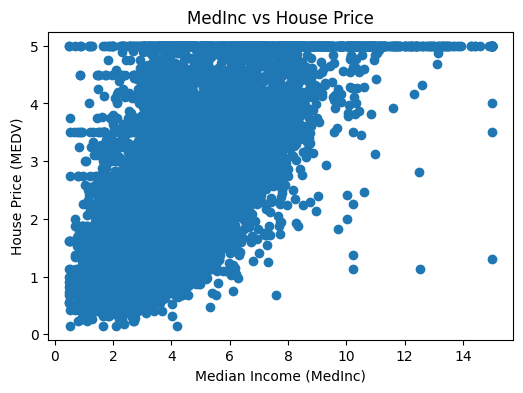

In [9]:
# --- EDA and Data Preprocessing ---
## Visualize the data
plt.figure(figsize=(6,4))
plt.scatter(df['MedInc'], df['MEDV'])
plt.xlabel("Median Income (MedInc)")
plt.ylabel("House Price (MEDV)")
plt.title("MedInc vs House Price")
plt.show()

In [10]:
# --- EDA and Data Preprocessing ---
## function to visualize the relationships between multiple features and the target variable
def scatter_plots(data, features, target):
    for feature in features:
        plt.figure(figsize=(5,4))
        plt.scatter(data[feature], data[target])
        plt.xlabel(feature)
        plt.ylabel(target)
        plt.title(f"{feature} vs {target}")
        plt.show()

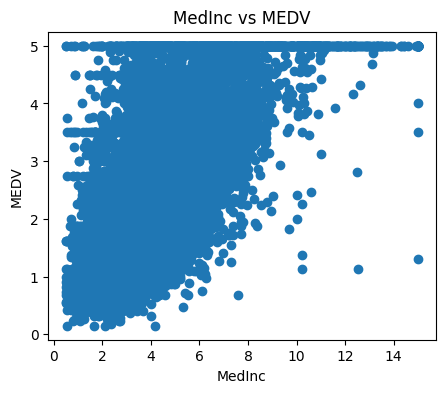

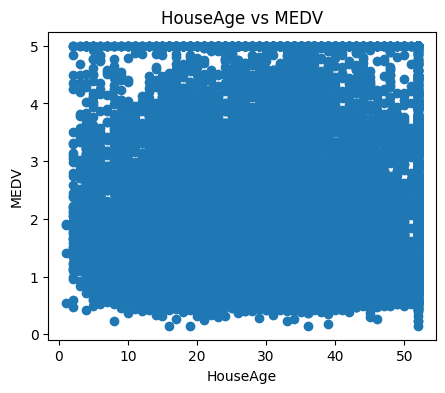

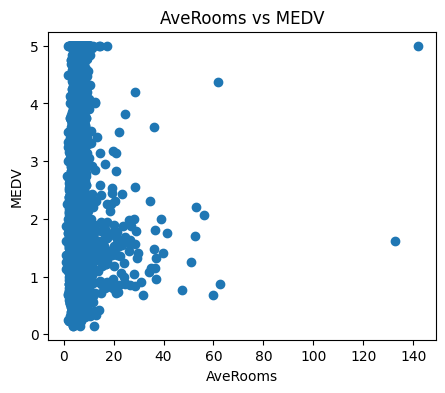

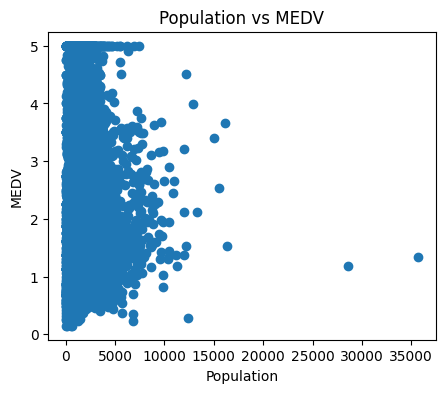

In [11]:
# --- EDA and Data Preprocessing ---
## Use the function to visualize the relationships between multiple features and the target variable
features = ['MedInc', 'HouseAge', 'AveRooms', 'Population']
scatter_plots(df, features, 'MEDV')

In [12]:
# --- ML Model Training ---
## Define X (features) and y (target)
X = df.drop('MEDV', axis=1)
y = df['MEDV']

## Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
# --- ML Model Training ---
## Choose an appropriate regression model
model = RandomForestRegressor(n_estimators=100, random_state=42)

## Train the model on the training data
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [14]:
# --- Model Evaluation ---
## Evaluate the performance of the model on the test set
# Predictions
y_pred = model.predict(X_test)

# MSE
mse = mean_squared_error(y_test, y_pred)

# RMSE
rmse = np.sqrt(mse)

# R-squared
r2 = r2_score(y_test, y_pred)

print("Model Performance")
print("MSE:", mse)
print("RMSE:", rmse)
print("R-squared:", r2)

Model Performance
MSE: 0.2553684927247781
RMSE: 0.5053399773665033
R-squared: 0.8051230593157366


In [15]:
# Parameter Tuning
model_tuned = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)

## Train the tuned model on the training data
model_tuned.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, n_estimators=200, random_state=42)

In [16]:
# ----Tuned Model Evaluation----
# Evaluate the performance of the tuned model on the test set
# Predictions
y_pred_tuned = model_tuned.predict(X_test)

# MSE
mse_tuned = mean_squared_error(y_test, y_pred_tuned)

# RMSE
rmse_tuned = np.sqrt(mse_tuned)

# R-squared
r2_tuned = r2_score(y_test, y_pred_tuned)

print("Tuned Model Performance")
print("MSE:", mse_tuned)
print("RMSE:", rmse_tuned)
print("R-squared:", r2_tuned)

Tuned Model Performance
MSE: 0.29513800051156747
RMSE: 0.5432660494744426
R-squared: 0.774774131273305


In [17]:
# --- Model Prediction ---
## Predict house prices from a new set of feature inputs
# Example new data for California housing (8 features: MedInc, HouseAge, AveRooms, AveBedrms, Population, AveOccup, Latitude, Longitude)
new_house_data = np.array([[8.3252, 41.0, 6.98412698, 1.02380952, 322.0, 2.55555556, 37.88, -122.23]])

prediction = model.predict(new_house_data)

print("Predicted House Price:", prediction)

Predicted House Price: [4.265793]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [19]:
!git add Assignment7.ipynb

fatal: pathspec 'Assignment7.ipynb' did not match any files


In [ ]:
!git commit -m "Add Assignment 7"